In [7]:
import nest_asyncio
nest_asyncio.apply()

from ib_insync import *

# Connect to IB TWS / IB Gateway
ib = IB()
ib.connect('127.0.0.1', 7496, clientId=103)

<IB connected to 127.0.0.1:7496 clientId=103>

Error 200, reqId 289: No security definition has been found for the request, contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250411', strike=150.0, right='C', exchange='SMART')
Error 10089, reqId 290: Requested market data requires additional subscription for API. See link in 'Market Data Connections' dialog for more details.SPY ARCA/TOP/ALL, contract: Stock(conId=756733, symbol='SPY', exchange='SMART', primaryExchange='ARCA', currency='USD', localSymbol='SPY', tradingClass='SPY')
Error 10089, reqId 291: Requested market data requires additional subscription for API. See link in 'Market Data Connections' dialog for more details.SPY ARCA/TOP/ALL, contract: Stock(conId=756733, symbol='SPY', exchange='SMART', primaryExchange='ARCA', currency='USD', localSymbol='SPY', tradingClass='SPY')
Error 10089, reqId 292: Requested market data requires additional subscription for API. See link in 'Market Data Connections' dialog for more details.SPY ARCA/TOP/ALL, contract: Stock(conId=

# Retrieve basic account values

In [8]:
account_values = ib.accountValues()
print("ACCOUNT VALUES:", account_values)

account_summary = ib.accountSummary()
print("\nACCOUNT SUMMARY:", account_summary)

positions = ib.positions()
print("\nCURRENT POSITIONS:")
for pos in positions:
    symbol = pos.contract.symbol
    quantity = pos.position
    avg_cost = pos.avgCost
    print(f"Symbol: {symbol}, Quantity: {quantity}, Avg Cost: {avg_cost}")


ACCOUNT VALUES: [AccountValue(account='U7215247', tag='AccountCode', value='U7215247', currency='', modelCode=''), AccountValue(account='U7215247', tag='AccountOrGroup', value='U7215247', currency='BASE', modelCode=''), AccountValue(account='U7215247', tag='AccountOrGroup', value='U7215247', currency='EUR', modelCode=''), AccountValue(account='U7215247', tag='AccountOrGroup', value='U7215247', currency='USD', modelCode=''), AccountValue(account='U7215247', tag='AccountReady', value='true', currency='', modelCode=''), AccountValue(account='U7215247', tag='AccountType', value='INDIVIDUAL', currency='', modelCode=''), AccountValue(account='U7215247', tag='AccruedCash', value='0.00', currency='BASE', modelCode=''), AccountValue(account='U7215247', tag='AccruedCash', value='0.00', currency='EUR', modelCode=''), AccountValue(account='U7215247', tag='AccruedCash', value='0.00', currency='USD', modelCode=''), AccountValue(account='U7215247', tag='AccruedDividend', value='0.00', currency='EUR',

# Objective

- Plot the volatility surface of SPY

In [10]:
def get_option_chains():
    """
    Returns a sorted list of all available expiration dates for SPY options.
    """
    # Define and qualify the SPY contract
    spy = Stock('SPY', 'SMART', 'USD')
    ib.qualifyContracts(spy)
    chains = ib.reqSecDefOptParams(spy.symbol, '', spy.secType, spy.conId)
    #ticker = ib.reqMktData(option_contract, '', False, False)
    return chains
    #print(chains)
spy_expirations = get_option_chains()

spy_expirations

[OptionChain(exchange='NASDAQOM', underlyingConId='756733', tradingClass='SPY', multiplier='100', expirations=['20250411', '20250414', '20250415', '20250416', '20250417', '20250421', '20250422', '20250423', '20250424', '20250425', '20250430', '20250502', '20250509', '20250516', '20250523', '20250530', '20250620', '20250630', '20250718', '20250731', '20250815', '20250829', '20250919', '20250930', '20251219', '20251231', '20260116', '20260320', '20260331', '20260618', '20261218', '20270115', '20271217'], strikes=[150.0, 155.0, 160.0, 165.0, 170.0, 175.0, 180.0, 185.0, 190.0, 195.0, 200.0, 205.0, 210.0, 215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0, 250.0, 255.0, 260.0, 265.0, 270.0, 275.0, 280.0, 285.0, 290.0, 295.0, 300.0, 305.0, 310.0, 315.0, 316.0, 317.0, 318.0, 319.0, 320.0, 321.0, 322.0, 323.0, 324.0, 325.0, 326.0, 327.0, 328.0, 329.0, 330.0, 331.0, 332.0, 333.0, 334.0, 335.0, 336.0, 337.0, 338.0, 339.0, 340.0, 341.0, 342.0, 343.0, 344.0, 345.0, 346.0, 347.0, 348.0, 349.0, 350.0, 

In [11]:
smart_chain = [chain for chain in spy_expirations if chain.exchange == 'SMART']
smart_chain = smart_chain[0] if smart_chain else None

smart_chain

OptionChain(exchange='SMART', underlyingConId='756733', tradingClass='SPY', multiplier='100', expirations=['20250411', '20250414', '20250415', '20250416', '20250417', '20250421', '20250422', '20250423', '20250424', '20250425', '20250430', '20250502', '20250509', '20250516', '20250523', '20250530', '20250620', '20250630', '20250718', '20250731', '20250815', '20250829', '20250919', '20250930', '20251219', '20251231', '20260116', '20260320', '20260331', '20260618', '20261218', '20270115', '20271217'], strikes=[150.0, 155.0, 160.0, 165.0, 170.0, 175.0, 180.0, 185.0, 190.0, 195.0, 200.0, 205.0, 210.0, 215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0, 250.0, 255.0, 260.0, 265.0, 270.0, 275.0, 280.0, 285.0, 290.0, 295.0, 300.0, 305.0, 310.0, 315.0, 316.0, 317.0, 318.0, 319.0, 320.0, 321.0, 322.0, 323.0, 324.0, 325.0, 326.0, 327.0, 328.0, 329.0, 330.0, 331.0, 332.0, 333.0, 334.0, 335.0, 336.0, 337.0, 338.0, 339.0, 340.0, 341.0, 342.0, 343.0, 344.0, 345.0, 346.0, 347.0, 348.0, 349.0, 350.0, 351.

In [48]:
spy = Stock('SPY', 'SMART', 'USD')
ib.qualifyContracts(spy)
spy_contract = ib.reqContractDetails(spy)
#chains = ib.reqSecDefOptParams(spy_contract.symbol, '', spy_contract.secType, spy_contract.conId)
chains = ib.reqSecDefOptParams(spy.symbol, '', spy.secType, spy.conId)
smart_chain = [chain for chain in chains if chain.exchange == 'SMART']
smart_chain = smart_chain[0] if smart_chain else None

#expirations = sorted(smart_chain.expirations)
#strikes = sorted(smart_chain.strikes)
#spy_call_contract = Option(spy.symbol, expirations[0], strikes[0], 'C', 'SMART')


expirations = smart_chain.expirations[15]
spy_call_contracts = []

for strike in smart_chain.strikes:
    contract = Option(spy.symbol, expirations, strike, 'C', 'SMART')
    spy_call_contracts.append(contract)

qualified_contracts = ib.qualifyContracts(*spy_call_contracts)

market_data = []

for contract in qualified_contracts:
    qualCon = ib.reqMktData(contract, '', False, False)
    market_data.append(qualCon)

Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=150.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=155.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=160.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=165.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=170.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=175.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=180.0, right='C', exchange='SMART')
Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=185.0, right='C', exchange='SMART')
Unknown contract

In [52]:
contract_details = [ib.reqContractDetails(contract)[0] for contract in qualified_contracts]
contract_details

[ContractDetails(contract=Contract(secType='OPT', conId=775268774, symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=300.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='SPY   250530C00300000', tradingClass='SPY'), marketName='SPY', minTick=0.01, orderTypes='ACTIVETIM,AD,ADJUST,ALERT,ALGO,ALLOC,AON,AVGCOST,BASKET,COND,CONDORDER,DAY,DEACT,DEACTDIS,DEACTEOD,DIS,FOK,GAT,GTC,GTD,GTT,HID,ICE,IOC,LIT,LMT,MIT,MKT,MTL,NGCOMB,NONALGO,OCA,OPENCLOSE,PAON,PEGMIDVOL,PEGMKTVOL,PEGPRMVOL,PEGSRFVOL,POSTONLY,PRICECHK,REL,RELPCTOFS,RELSTK,SCALE,SCALERST,SIZECHK,SMARTSTG,SNAPMID,SNAPMKT,SNAPREL,STP,STPLMT,TRAIL,TRAILLIT,TRAILLMT,TRAILMIT,VOLAT,WHATIF', validExchanges='SMART,AMEX,CBOE,PHLX,PSE,ISE,BOX,BATS,NASDAQOM,CBOE2,NASDAQBX,MIAX,GEMINI,EDGX,MERCURY,PEARL,EMERALD,MEMX,IBUSOPT,SAPPHIRE', priceMagnifier=1, underConId=756733, longName='SPDR S&P 500 ETF TRUST', contractMonth='202505', industry='', category='', subcategory='', timeZoneId='US/Eastern', tradingHours

In [59]:
contract_details[0]

ContractDetails(contract=Contract(secType='OPT', conId=775268774, symbol='SPY', lastTradeDateOrContractMonth='20250530', strike=300.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='SPY   250530C00300000', tradingClass='SPY'), marketName='SPY', minTick=0.01, orderTypes='ACTIVETIM,AD,ADJUST,ALERT,ALGO,ALLOC,AON,AVGCOST,BASKET,COND,CONDORDER,DAY,DEACT,DEACTDIS,DEACTEOD,DIS,FOK,GAT,GTC,GTD,GTT,HID,ICE,IOC,LIT,LMT,MIT,MKT,MTL,NGCOMB,NONALGO,OCA,OPENCLOSE,PAON,PEGMIDVOL,PEGMKTVOL,PEGPRMVOL,PEGSRFVOL,POSTONLY,PRICECHK,REL,RELPCTOFS,RELSTK,SCALE,SCALERST,SIZECHK,SMARTSTG,SNAPMID,SNAPMKT,SNAPREL,STP,STPLMT,TRAIL,TRAILLIT,TRAILLMT,TRAILMIT,VOLAT,WHATIF', validExchanges='SMART,AMEX,CBOE,PHLX,PSE,ISE,BOX,BATS,NASDAQOM,CBOE2,NASDAQBX,MIAX,GEMINI,EDGX,MERCURY,PEARL,EMERALD,MEMX,IBUSOPT,SAPPHIRE', priceMagnifier=1, underConId=756733, longName='SPDR S&P 500 ETF TRUST', contractMonth='202505', industry='', category='', subcategory='', timeZoneId='US/Eastern', tradingHours=

In [63]:
for contract, data in zip(qualified_contracts, market_data):
    print(f"{contract.strike}C: bid={data.bid}, ask={data.ask}, last={data.last}")

300.0C: bid=226.23, ask=228.05, last=nan
305.0C: bid=221.23, ask=223.25, last=nan
310.0C: bid=216.38, ask=218.34, last=nan
315.0C: bid=211.54, ask=213.4, last=nan
320.0C: bid=206.56, ask=208.51, last=nan
325.0C: bid=201.68, ask=203.62, last=nan
330.0C: bid=196.86, ask=198.77, last=nan
335.0C: bid=191.94, ask=193.91, last=nan
340.0C: bid=187.52, ask=188.94, last=nan
345.0C: bid=182.67, ask=184.03, last=nan
350.0C: bid=177.48, ask=179.31, last=nan
355.0C: bid=172.85, ask=174.34, last=nan
360.0C: bid=167.81, ask=169.56, last=nan
365.0C: bid=163.36, ask=164.8, last=nan
370.0C: bid=158.38, ask=159.76, last=nan
375.0C: bid=153.97, ask=154.56, last=nan
380.0C: bid=149.19, ask=149.78, last=nan
385.0C: bid=144.42, ask=144.99, last=nan
390.0C: bid=139.67, ask=140.24, last=nan
395.0C: bid=134.93, ask=135.5, last=nan
400.0C: bid=130.21, ask=130.81, last=nan
405.0C: bid=125.51, ask=126.09, last=nan
410.0C: bid=120.88, ask=121.43, last=nan
415.0C: bid=116.18, ask=116.79, last=nan
420.0C: bid=111.6, 

In [62]:
ivs = []
underlying_price = ib.reqMktData(spy).last

underlying_price

ib.calculateImpliedVolatility(contract, 500, 525)

OptionComputation(tickAttrib=0, impliedVol=11.144548083353921, delta=None, optPrice=500.0, pvDividend=None, gamma=None, vega=-2.0, theta=-2.0, undPrice=525.0)

In [41]:
smart_chain.expirations[15] # just get one expiration for now.
#smart_chain.strikes

spy_stock_contract = ib.reqMktData(spy, '', False, False)
spy_stock_contract.last


915.0

# Objective

- We need:
    1) List of expiries
    2) Collect just closest expiry (i.e. today's)
    3) Collect whole options chain for today's expiry
        - Collect SPY's current market price
    4) Split into calls and puts data - with prices
    5) Create a function to buy a call with a strike + % of current market price - i.e. SPY = 540 - find strike 540*0.01 = 5.4 | strike = 59.4 (rounded up to 560)
        - Add in a stop loss function as a percent of max loss willing to take on a given trade (540-530)/530 * 100 gives us a 1.88% max loss
        - Add in a trailing take profit function. (Find some examples online)
            - idea: Set the trailing take profit to be 5% less than the all time high since entering the trade
            - i.e. if a option is trading at $100 and it manages to go up to $150 and our trailing take profit is 5% ($7.5) and the stock falls to 142.5 then we exit a portion of the trade, keep exiting as the stock falls. If it moves to 170 and we still have some options then out new trailing take profit would be ($8.5) or $161.5 for that batch of options we still own.

In [3]:
# 1)
from ib_insync import *

def get_spy_expiries():
    """
    Returns a sorted list of all available expiration dates for SPY options.
    """
    # Define and qualify the SPY contract
    spy = Stock('SPY', 'SMART', 'USD')
    ib.qualifyContracts(spy)
    chains = ib.reqSecDefOptParams(spy.symbol, '', spy.secType, spy.conId)
    return chains
    #print(chains)
spy_expirations = get_spy_expiries()

In [4]:
# spy_expirations[0].tradingClass #NOTE WE SHOULD USE THE smart EXCHANGE - NOT ALWAYS THE FIRST EXCAHANGE
# spy_expirations[0].underlyingConId
# spy_expirations[0].expirations
# spy_expirations[0].strikes


[150.0,
 155.0,
 160.0,
 165.0,
 170.0,
 175.0,
 180.0,
 185.0,
 190.0,
 195.0,
 200.0,
 205.0,
 210.0,
 215.0,
 220.0,
 225.0,
 230.0,
 235.0,
 240.0,
 245.0,
 250.0,
 255.0,
 260.0,
 265.0,
 270.0,
 275.0,
 280.0,
 285.0,
 290.0,
 295.0,
 300.0,
 305.0,
 310.0,
 315.0,
 320.0,
 325.0,
 330.0,
 335.0,
 340.0,
 345.0,
 350.0,
 355.0,
 360.0,
 365.0,
 370.0,
 375.0,
 380.0,
 385.0,
 390.0,
 391.0,
 392.0,
 393.0,
 394.0,
 395.0,
 396.0,
 397.0,
 398.0,
 399.0,
 400.0,
 401.0,
 402.0,
 403.0,
 404.0,
 405.0,
 406.0,
 407.0,
 408.0,
 409.0,
 410.0,
 411.0,
 412.0,
 413.0,
 414.0,
 415.0,
 416.0,
 417.0,
 418.0,
 419.0,
 420.0,
 421.0,
 422.0,
 423.0,
 424.0,
 425.0,
 426.0,
 427.0,
 428.0,
 429.0,
 430.0,
 431.0,
 432.0,
 433.0,
 434.0,
 435.0,
 436.0,
 437.0,
 438.0,
 439.0,
 440.0,
 441.0,
 442.0,
 443.0,
 444.0,
 445.0,
 446.0,
 447.0,
 448.0,
 449.0,
 450.0,
 451.0,
 452.0,
 453.0,
 454.0,
 455.0,
 456.0,
 457.0,
 458.0,
 459.0,
 460.0,
 461.0,
 462.0,
 463.0,
 464.0,
 465.0,
 466.0,


In [12]:

tick = spy_expirations[0].tradingClass
smart_chain = [chain for chain in spy_expirations if chain.exchange == 'SMART']

calls = []
puts = []
for strike in spy_expirations[0]:
    calls.append(Option(
        symbol = tick,
        lastTradeDateOrContractMonth = smart_chain,
        strike = strike,
        right = "C",
        exchange = "SMART"
        )
    )
    puts.append(Option(
        symbol = tick,
        lastTradeDateOrContractMonth = smart_chain,
        strike = strike,
        right = "P",
        exchange = "SMART"
    ))


qualified_contracts = ib.qualifyContracts(*calls, *puts)

Unknown contract: Option(symbol='SPY', lastTradeDateOrContractMonth=[OptionChain(exchange='SMART', underlyingConId='756733', tradingClass='SPY', multiplier='100', expirations=['20250404', '20250407', '20250408', '20250409', '20250410', '20250411', '20250414', '20250415', '20250416', '20250417', '20250425', '20250430', '20250502', '20250509', '20250516', '20250523', '20250530', '20250620', '20250630', '20250718', '20250731', '20250815', '20250829', '20250919', '20250930', '20251219', '20251231', '20260116', '20260320', '20260331', '20260618', '20261218', '20270115', '20271217'], strikes=[150.0, 155.0, 160.0, 165.0, 170.0, 175.0, 180.0, 185.0, 190.0, 195.0, 200.0, 205.0, 210.0, 215.0, 220.0, 225.0, 230.0, 235.0, 240.0, 245.0, 250.0, 255.0, 260.0, 265.0, 270.0, 275.0, 280.0, 285.0, 290.0, 295.0, 300.0, 305.0, 310.0, 315.0, 320.0, 325.0, 330.0, 335.0, 340.0, 345.0, 350.0, 355.0, 360.0, 365.0, 370.0, 375.0, 380.0, 385.0, 390.0, 391.0, 392.0, 393.0, 394.0, 395.0, 396.0, 397.0, 398.0, 399.0, 

In [11]:
spy = Stock('SPY', 'SMART', 'USD')
ib.qualifyContracts(spy)
ticker = ib.reqMktData(spy, '', snapshot=True)
ticker.marketPrice()


nan

# Analyse historical IB Data

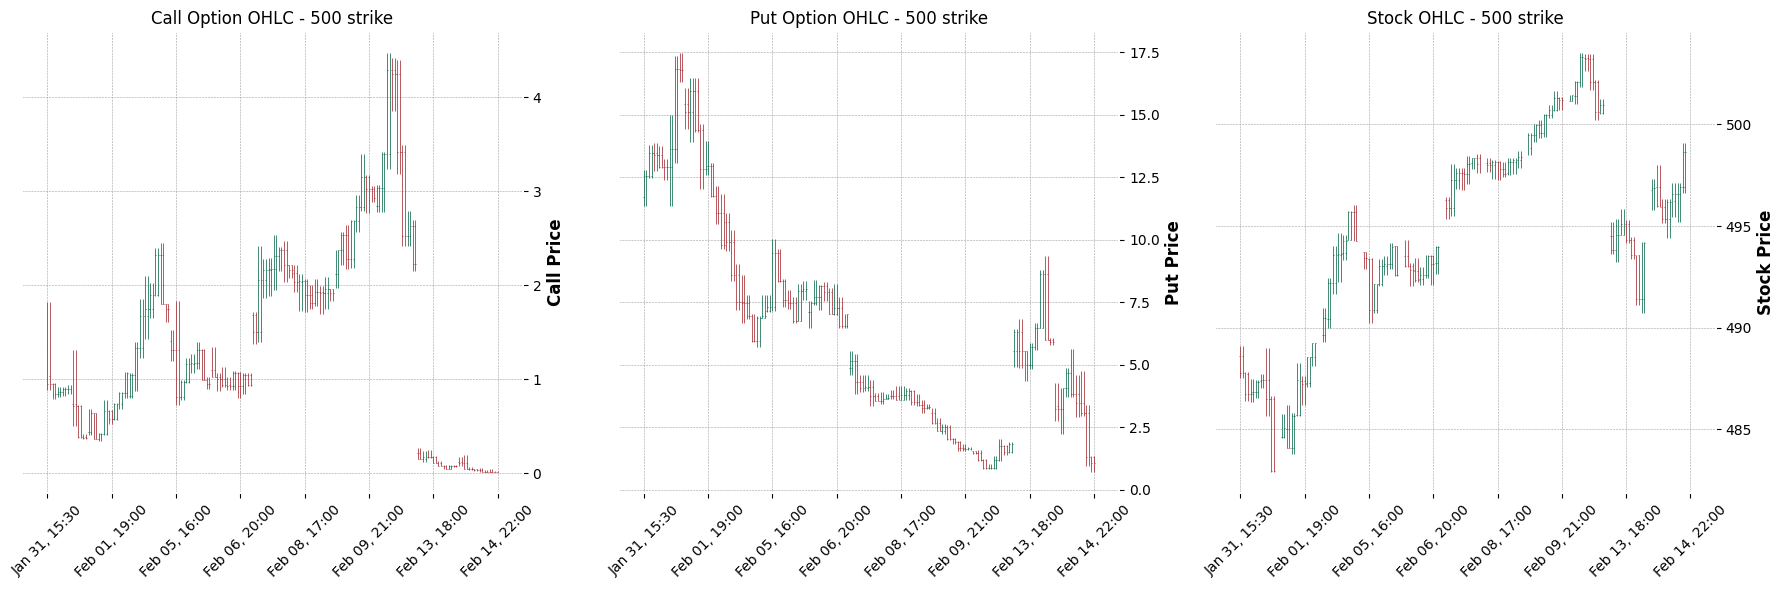

In [37]:
##file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_490.csv"
file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/projects/2025/trading/expiry_20240214_strike_500.csv"
#file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_510.csv"
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt

df = pd.read_csv(file)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

call_df = df[['call_open', 'call_high', 'call_low', 'call_close']].copy()
call_df.columns = ['Open', 'High', 'Low', 'Close']

put_df = df[['put_open', 'put_high', 'put_low', 'put_close']].copy()
put_df.columns = ['Open', 'High', 'Low', 'Close']


stock_df = df[['stock_open', 'stock_high', 'stock_low', 'stock_close']].copy()
stock_df.columns = ['Open', 'High', 'Low', 'Close']

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot without 'title' param
mpf.plot(call_df, type='ohlc', ax=axs[0], style='charles', ylabel='Call Price')
axs[0].set_title('Call Option OHLC - 500 strike')

mpf.plot(put_df, type='ohlc', ax=axs[1], style='charles', ylabel='Put Price')
axs[1].set_title('Put Option OHLC - 500 strike')

mpf.plot(stock_df, type='ohlc', ax=axs[2], style='charles', ylabel='Stock Price')
axs[2].set_title('Stock OHLC - 500 strike')

plt.tight_layout()
plt.show()



In [61]:
df

,call_open,call_high,call_low,call_close,put_open,put_high,put_low,put_close,stock_open,stock_high,stock_low,stock_close,stock_volume,day
date,,,,,,,,,,,,,,
2024-01-31 15:30:00,1.03,1.82,0.88,0.95,11.72,12.78,11.34,12.55,488.62,489.09,487.52,487.76,61890.0,31
2024-01-31 15:30:00,1.03,1.82,0.88,0.95,11.72,12.78,11.34,12.55,488.62,489.09,487.52,487.76,61890.0,31
2024-01-31 16:00:00,0.95,0.96,0.79,0.84,12.55,13.80,12.47,13.48,487.73,487.83,486.39,486.75,81468.0,31
2024-01-31 16:00:00,0.95,0.96,0.79,0.84,12.55,13.80,12.47,13.48,487.73,487.83,486.39,486.75,81468.0,31
2024-01-31 17:00:00,0.84,0.92,0.81,0.86,13.48,13.88,12.76,13.39,486.74,487.48,486.34,486.84,53420.0,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-02-14 20:00:00,0.01,0.03,0.01,0.01,3.47,4.77,2.94,3.08,496.58,497.11,495.22,496.92,59510.0,14
2024-02-14 21:00:00,0.01,0.04,0.01,0.01,3.08,3.38,0.96,1.30,496.92,499.07,496.61,498.63,135015.0,14
2024-02-14 21:00:00,0.01,0.04,0.01,0.01,3.08,3.38,0.96,1.30,496.92,499.07,496.61,498.63,135015.0,14


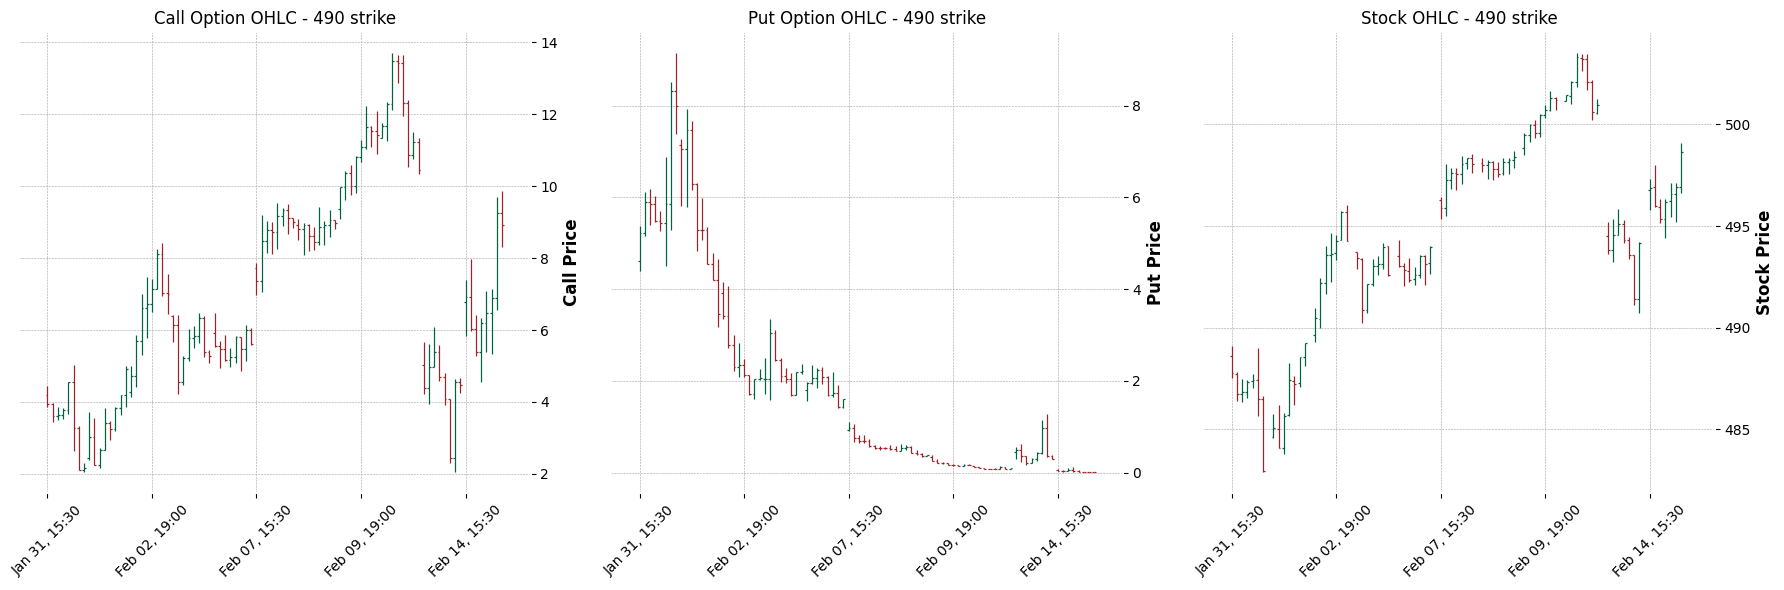

In [38]:
file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_490.csv"
#file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/projects/2025/trading/expiry_20240214_strike_500.csv"
#file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_510.csv"
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt

df = pd.read_csv(file)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

call_df = df[['call_open', 'call_high', 'call_low', 'call_close']].copy()
call_df.columns = ['Open', 'High', 'Low', 'Close']

put_df = df[['put_open', 'put_high', 'put_low', 'put_close']].copy()
put_df.columns = ['Open', 'High', 'Low', 'Close']


stock_df = df[['stock_open', 'stock_high', 'stock_low', 'stock_close']].copy()
stock_df.columns = ['Open', 'High', 'Low', 'Close']

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot without 'title' param
mpf.plot(call_df, type='ohlc', ax=axs[0], style='charles', ylabel='Call Price')
axs[0].set_title('Call Option OHLC - 490 strike')

mpf.plot(put_df, type='ohlc', ax=axs[1], style='charles', ylabel='Put Price')
axs[1].set_title('Put Option OHLC - 490 strike')

mpf.plot(stock_df, type='ohlc', ax=axs[2], style='charles', ylabel='Stock Price')
axs[2].set_title('Stock OHLC - 490 strike')

plt.tight_layout()
plt.show()

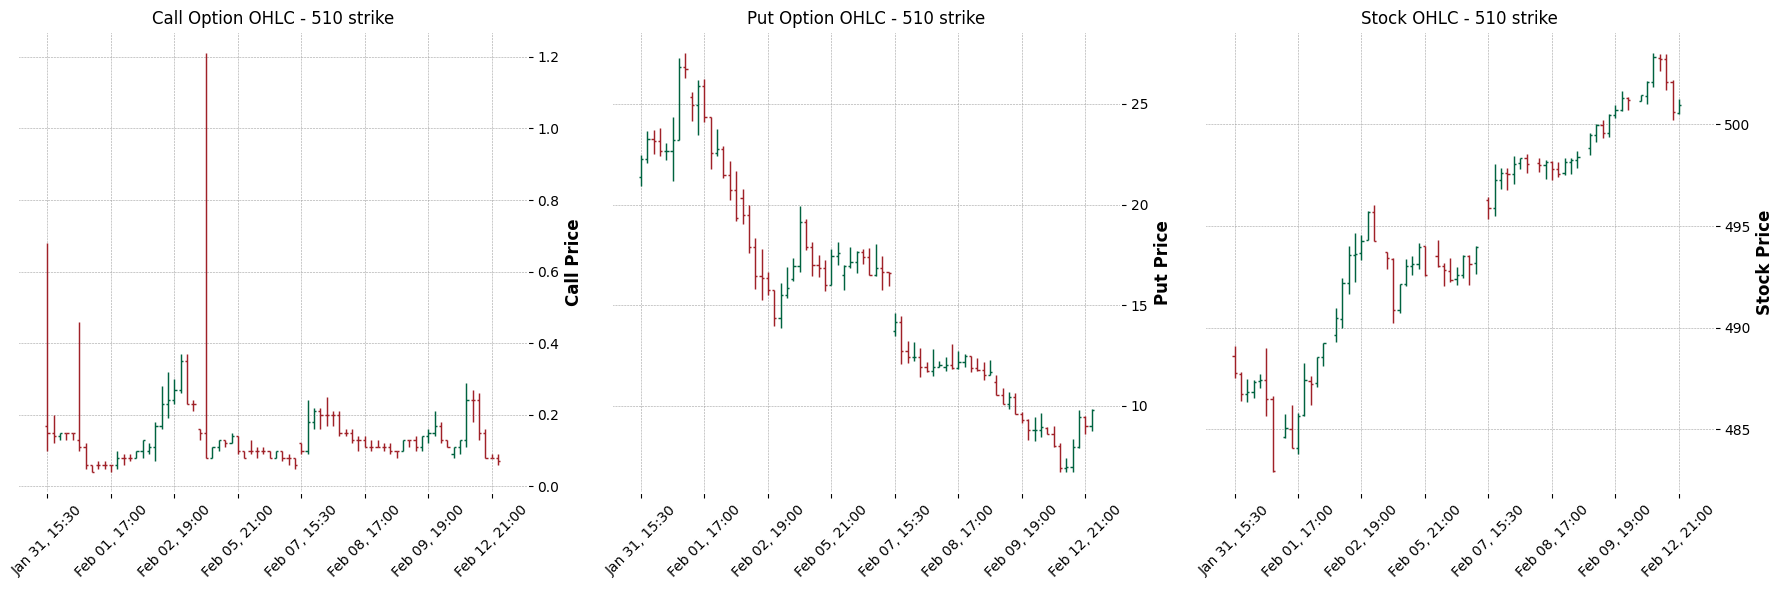

In [40]:
#file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_490.csv"
#file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/projects/2025/trading/expiry_20240214_strike_500.csv"
file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_510.csv"
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt

df = pd.read_csv(file)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

call_df = df[['call_open', 'call_high', 'call_low', 'call_close']].copy()
call_df.columns = ['Open', 'High', 'Low', 'Close']

put_df = df[['put_open', 'put_high', 'put_low', 'put_close']].copy()
put_df.columns = ['Open', 'High', 'Low', 'Close']


stock_df = df[['stock_open', 'stock_high', 'stock_low', 'stock_close']].copy()
stock_df.columns = ['Open', 'High', 'Low', 'Close']

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot without 'title' param
mpf.plot(call_df, type='ohlc', ax=axs[0], style='charles', ylabel='Call Price')
axs[0].set_title('Call Option OHLC - 510 strike')

mpf.plot(put_df, type='ohlc', ax=axs[1], style='charles', ylabel='Put Price')
axs[1].set_title('Put Option OHLC - 510 strike')

mpf.plot(stock_df, type='ohlc', ax=axs[2], style='charles', ylabel='Stock Price')
axs[2].set_title('Stock OHLC - 510 strike')

plt.tight_layout()
plt.show()

# Analyse the 500 strike

In [68]:
##file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_490.csv"
file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/projects/2025/trading/expiry_20240214_strike_500.csv"
#file = "/run/media/matt/629ca719-0707-422e-a5c5-51e0f75a499b/Options/data/expiry_20240214_strike_510.csv"
import pandas as pd
import mplfinance as mpf
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)

df = pd.read_csv(file)
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df['day'] = df.index.day
df = df.drop_duplicates()
df

,call_open,call_high,call_low,call_close,put_open,put_high,put_low,put_close,stock_open,stock_high,stock_low,stock_close,stock_volume,day
date,,,,,,,,,,,,,,
2024-01-31 15:30:00,1.03,1.82,0.88,0.95,11.72,12.78,11.34,12.55,488.62,489.09,487.52,487.76,61890.0,31
2024-01-31 16:00:00,0.95,0.96,0.79,0.84,12.55,13.80,12.47,13.48,487.73,487.83,486.39,486.75,81468.0,31
2024-01-31 17:00:00,0.84,0.92,0.81,0.86,13.48,13.88,12.76,13.39,486.74,487.48,486.34,486.84,53420.0,31
2024-01-31 18:00:00,0.86,0.92,0.82,0.89,13.39,13.73,12.87,12.92,486.85,487.41,486.56,487.34,39828.0,31
2024-01-31 19:00:00,0.89,0.94,0.84,0.90,12.92,13.21,12.39,12.90,487.35,487.71,487.03,487.43,42194.0,31
2024-01-31 20:00:00,0.74,1.31,0.50,0.71,12.90,14.99,11.33,13.62,487.43,489.00,485.63,486.48,185781.0,31
2024-01-31 21:00:00,0.71,0.72,0.37,0.38,13.62,17.35,13.06,16.83,486.50,486.62,482.89,482.92,366162.0,31
2024-01-31 22:00:00,0.38,0.42,0.36,0.37,16.83,17.45,16.30,16.77,NaN,NaN,NaN,NaN,NaN,31
2024-02-01 15:30:00,0.44,0.68,0.41,0.64,15.42,16.07,14.42,15.11,484.63,485.75,484.56,485.08,71840.0,1


In [54]:
def get_gap_fill_analytics(df, abs_pct_gap=0.0002):
    
    # Calculate  Opening Gap % and its absolute value
    df['Prev_Close']=df['stock_close'].shift(1)
    df['Opening_Gap']=(df['stock_open']-df['Prev_Close'])/df['Prev_Close']
    df['Opening_Gap_Abs']=df['Opening_Gap'].abs()
 
    # Is there a Gap Up, Gap Down, or No Gap.
    df['Gap_Down']=df['Opening_Gap']<0
    df['Gap_Up']=df['Opening_Gap']>0
    df['No_Gap']=df['Opening_Gap']==0

   
    ### Check if Gap Up/Down Filled Filled
    df['Gap_Up_Filled']=df['stock_low']<df['Prev_Close']
    df['Gap_Down_Filled']=df['stock_high']>df['Prev_Close']

    abs_gap_down = df[(df.Gap_Down) & (df.Opening_Gap<=-abs_pct_gap)]['Gap_Down_Filled'].mean()
    abs_gap_up = df[(df.Gap_Up) & (df.Opening_Gap>=abs_pct_gap)]['Gap_Up_Filled'].mean()

    return [abs_gap_down, abs_gap_up]


get_gap_fill_analytics(df)

                     call_open  call_high  call_low  call_close  put_open  \
date                                                                        
2024-01-31 15:30:00       1.03       1.82      0.88        0.95     11.72   
2024-01-31 15:30:00       1.03       1.82      0.88        0.95     11.72   
2024-01-31 16:00:00       0.95       0.96      0.79        0.84     12.55   
2024-01-31 16:00:00       0.95       0.96      0.79        0.84     12.55   
2024-01-31 17:00:00       0.84       0.92      0.81        0.86     13.48   
...                        ...        ...       ...         ...       ...   
2024-02-14 20:00:00       0.01       0.03      0.01        0.01      3.47   
2024-02-14 21:00:00       0.01       0.04      0.01        0.01      3.08   
2024-02-14 21:00:00       0.01       0.04      0.01        0.01      3.08   
2024-02-14 22:00:00       0.01       0.02      0.01        0.01      1.30   
2024-02-14 22:00:00       0.01       0.02      0.01        0.01      1.30   

[0.9767441860465116, 1.0]